<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/smith-ramirez/JohnSmithclase2_visualizacionEscalar2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tipos de datos en visualización científica exploratoria
**Clase 2 — ¿De dónde vienen los datos? ¿Cómo se representan?**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---

## Visualización de campos escalares en dos dimensiones

Cuando los datos son bidimensionales la estrategia natural es asignar cada dimensión del dato a una dimensión de la pantalla: el eje horizontal para $x$, el eje vertical para $y$, y el **valor escalar** $z = f(x,y)$ a un color o a la altura de una superficie.

Las tres representaciones principales que veremos son:

| Representación | Qué muestra | Función matplotlib |
|---|---|---|
| **Imagen rasterizada** | El valor en cada punto como un color directo | `imshow`, `pmesh`,`pcolormesh` |
| **Superficie deformada** | El valor $z$ como altura en una escena 3D | `plot_surface` |
| **Isocontornos** | Curvas donde $f = $ constante | `contour`, `contourf` |

Cada representación resalta aspectos distintos del mismo campo. Lo usual es combinarlas.

## 0. Configuración de estilo

In [2]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

#!pip install colorspacious

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


In [1]:
# Instalación de dependencias de LaTeX (tarda unos 2-3 min)
#!apt-get install texlive texlive-latex-extra texlive-fonts-recommended dvipng cm-super

---
## 1. Datos de prueba: función `peaks`

Usamos la función clásica `peaks`, definida como:

$$
f(x,y) = 3(1-x)^2 e^{-x^2-(y+1)^2}
        - 10\!\left(\frac{x}{5} - x^3 - y^5\right)e^{-x^2-y^2}
        - \frac{1}{3}e^{-(x+1)^2-y^2}
$$

Es útil como dato de prueba porque:
- tiene varios **máximos y mínimos locales** (picos y valles),
- sus valores son tanto **positivos como negativos**
- es suave, sin singularidades.

In [ ]:
def peaks(n=80):
    """Función peaks de MATLAB. Devuelve x, y, z como arrays (n, n)."""
    # mgrid con paso complejo: n puntos en [-3, 3] en cada dirección
    x, y = np.mgrid[-3:3:n*1j, -3:3:n*1j]

    z = (  3*(1 - x)**2 * np.exp(-x**2 - (y + 1)**2)
         - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2)
         - 1/3 * np.exp(-(x + 1)**2 - y**2) )
    return x, y, z

x, y, z = peaks(n=80)

print(f'Forma de x: {x.shape}')          # (80, 80)
print(f'Rango de z: [{z.min():.2f}, {z.max():.2f}]')  # valores +/-
print(f'¿x varía por filas o columnas? x[:,0] constante: {np.allclose(x[:,0], x[:,0][0])}')
print(z.shape)
# → False: x varía por filas (primer índice), y varía por columnas (segundo índice)

Forma de x: (80, 80)
Rango de z: [-6.54, 8.09]
¿x varía por filas o columnas? x[:,0] constante: False
(80, 80)


### Construcción de mallas con `np.mgrid` o `np.meshgrid`.

- ¿Cuál es el dominio de la función Peak?

- ¿Cuál es el rango?

- `np.mgrid[-3:3:80j, -3:3:80j]` genera dos arrays 2D de forma `(80, 80)`:  el `80j` indica **80 puntos** en el intervalo cerrado `[-3, 3]` (la `j` es la sintaxis de mgrid que indica número de puntos, no tamaño de paso).

**¿Cuál es la diferencia con np.meshgrid?** (Cambiar el código a `np.meshgrid`)

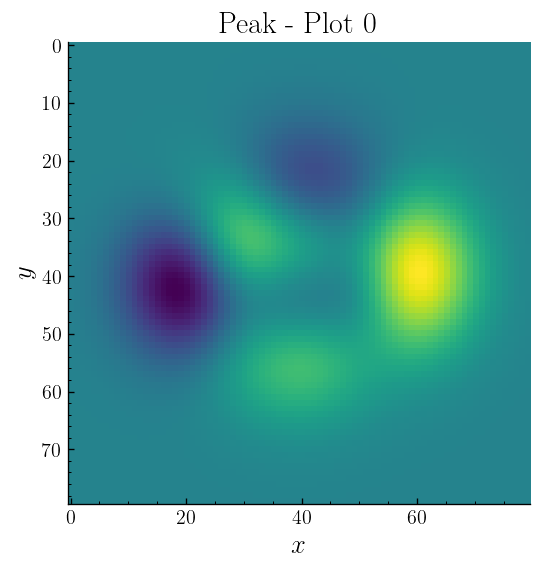

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.imshow(z)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Peak - Plot 0')

plt.show()


---
## 2. ¿Qué colormap elegir?

- En el rango de $z$ hay valores positivos y negativos con una asimetría leve.  
- El dato *cruza el cero*  
- Si usamos un color (secuencial), el cero no tiene ningún color especial y la estructura positivo/negativo se pierde visualmente.
- ¿Qué pasa cuando usamor jet?


### Peter Kovesi. Good Colour Maps: How to Design Them. arXiv:1509.03700 [cs.GR] 2015

La luminosidad es el factor más importante. Un mapa de colores exitoso debería poder imprimirse en blanco y negro y seguir siendo interpretable. Si la curva de luminosidad no es lineal (o divergente de forma clara), el mapa engañará al ojo creando estructuras artificiales en los datos.

**¿Cómo verificarlo? (El Test de la Rampa)**
Kovesi sugiere usar una rampa con una pequeña ondulación sinusoidal
- Si el mapa es bueno, deberías ver las ondulaciones de forma clara y uniforme a lo largo de toda la rampa.
- Si el mapa es malo, las ondas desaparecerán en algunas zonas (puntos muertos) o se verán exageradas en otras (artefactos).

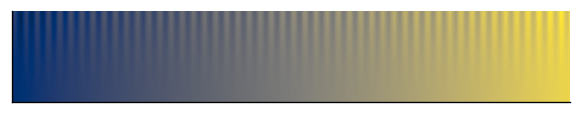

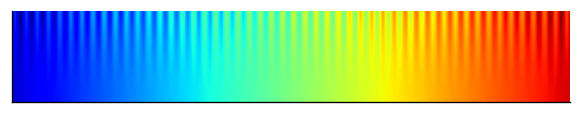

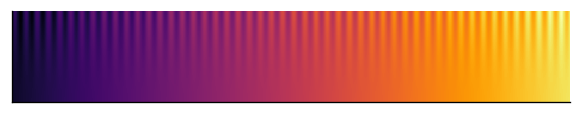

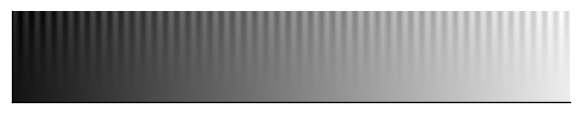

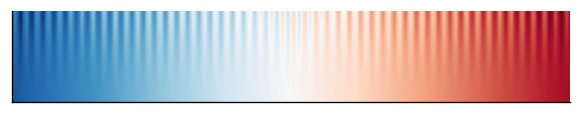

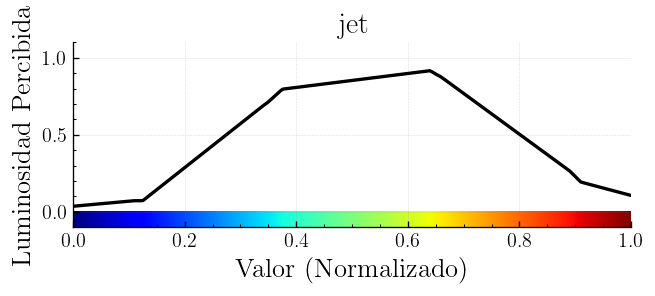

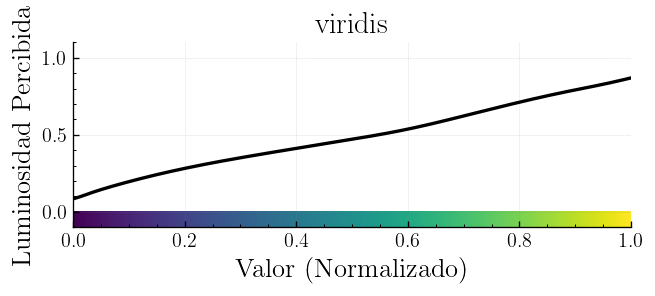

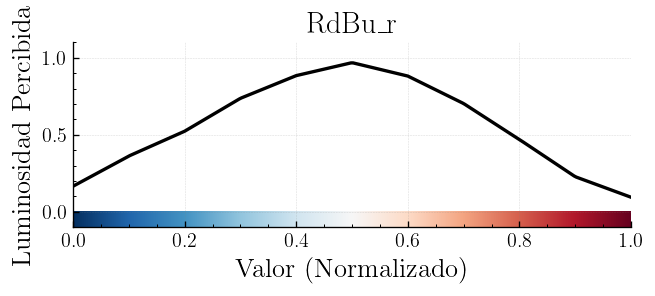

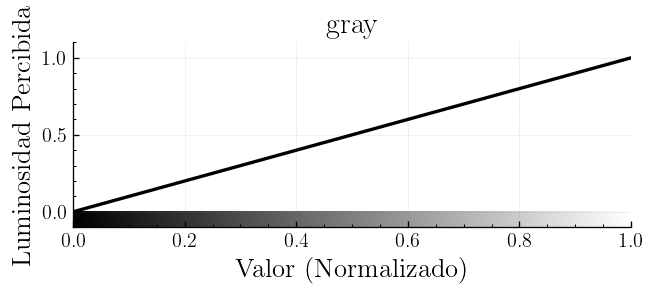

In [ ]:
def sine_ramp(y_max=1, y_min=0.0, amp=np.pi/5, cycles=50,
                     power=2, ny=50, nx=1025):
    """
    Crea una rampa de valores con una perturbación sinusoidal (ondas).
    Sirve para evaluar la resolución perceptual local y global.
    """
    # Genera una malla de coordenadas (ny filas por nx columnas)
    y, x = np.mgrid[y_min:y_max:ny*1j, 0:2*np.pi:nx*1j]

    # Normaliza 'y' para que vaya de 0 a 1 (eje vertical)
    y_norm = (y - y_min)/(y_max - y_min)

    # La clave de Kovesi:
    # 1. 'x' es la rampa base (aumenta linealmente).
    # 2. 'np.sin(cycles*x)' añade ondas pequeñas.
    # 3. 'y_norm**power' hace que las ondas sean casi invisibles arriba
    #    y muy marcadas abajo para evaluar el contraste.
    vals = amp * y_norm**power * np.sin(cycles*x) + x
    return x, y, vals

# Generamos los datos del test
xramp, yramp, vals = sine_ramp()

plt.figure(figsize=(6, 2))
plt.pcolormesh(xramp, yramp, vals, cmap="cividis")
plt.axis("image")
plt.xticks([])
plt.yticks([])
plt.show()
plt.figure(figsize=(6, 2))
plt.pcolormesh(xramp, yramp, vals, cmap="jet")
plt.axis("image")
plt.xticks([])
plt.yticks([])
plt.show()
plt.figure(figsize=(6, 2))
plt.pcolormesh(xramp, yramp, vals, cmap="inferno")
plt.axis("image")
plt.xticks([])
plt.yticks([])
plt.show()
plt.figure(figsize=(6, 2))
plt.pcolormesh(xramp, yramp, vals, cmap="gray")
plt.axis("image")
plt.xticks([])
plt.yticks([])
plt.show()
plt.figure(figsize=(6, 2))
plt.pcolormesh(xramp, yramp, vals, cmap="RdBu_r")
plt.axis("image")
plt.xticks([])
plt.yticks([])
plt.show()

from matplotlib import colormaps

def plot_luminance(cmap_name):
    # 1. Obtener el mapa de colores y crear un rango de 0 a 1
    cmap = colormaps.get_cmap(cmap_name)
    x = np.linspace(0, 1, 256)
    rgb = cmap(x)[:, :3]  # Extraer canales R, G, B

    # 2. Calcular la luminosidad percibida (Fórmula estándar ITU-R BT.709)
    # Los pesos reflejan que el ojo humano es más sensible al verde y menos al azul
    luminance = 0.2126 * rgb[:, 0] + 0.7152 * rgb[:, 1] + 0.0722 * rgb[:, 2]

    # 3. Graficar
    plt.figure(figsize=(6, 2))

    # Mostrar la barra del colormap abajo
    plt.imshow([x], extent=[0, 1, -0.1, 0], cmap=cmap, aspect='auto')

    # Graficar la curva de luminosidad
    plt.plot(x, luminance, color='black', lw=2)

    plt.title(f"{cmap_name}")
    plt.xlabel("Valor (Normalizado)")
    plt.ylabel("Luminosidad Percibida")
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

# Comparación: El "malo" vs el "bueno"
plot_luminance("jet")      # Verás muchos picos y valles (causa falsos artefactos)
plot_luminance("viridis")  # Verás una línea recta casi perfecta (perceptualmente uniforme)
plot_luminance("RdBu_r")
plot_luminance("gray")

### Accesibilidad y colorblindness

colorspacious (pip install colorspacious) — simula visión con deuteranopía, protanopía y tritanopía sobre cualquier colormap.

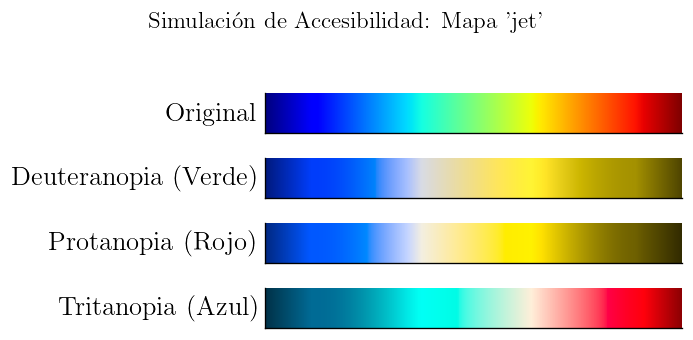

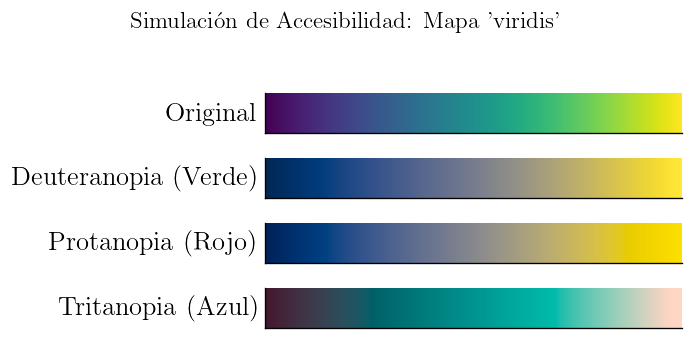

In [ ]:
from colorspacious import cspace_convert # type: ignore

def simulate_colorblindness(cmap_name):

    cmap = colormaps.get_cmap(cmap_name)
    gradient = np.linspace(0, 1, 256)
    rgb = cmap(gradient)[:, :3]               # shape (256, 3)

    types = [
        ("Original",              None),
        ("Deuteranopia (Verde)",  "deuteranomaly"),
        ("Protanopia (Rojo)",     "protanomaly"),
        ("Tritanopia (Azul)",     "tritanomaly"),
    ]

    fig, axs = plt.subplots(len(types), 1, figsize=(6, 3))
    fig.suptitle(f"Simulación de Accesibilidad: Mapa '{cmap_name}'", fontsize=14)

    for i, (label, cvd_type) in enumerate(types):
        if cvd_type:
            cvd_space = {"name": "sRGB1+CVD", "cvd_type": cvd_type, "severity": 100}
            display_rgb = np.clip(cspace_convert(rgb, cvd_space, "sRGB1"), 0, 1)
        else:
            display_rgb = rgb                 # shape (256, 3)

        # imshow espera (H, W, 3): envolvemos en lista → (1, 256, 3)
        axs[i].imshow([display_rgb], aspect='auto', extent=[0, 1, 0, 1])
        axs[i].set_ylabel(label, rotation=0, ha='right', va='center')
        axs[i].set_xticks([])
        axs[i].set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

simulate_colorblindness("jet")
simulate_colorblindness("viridis")

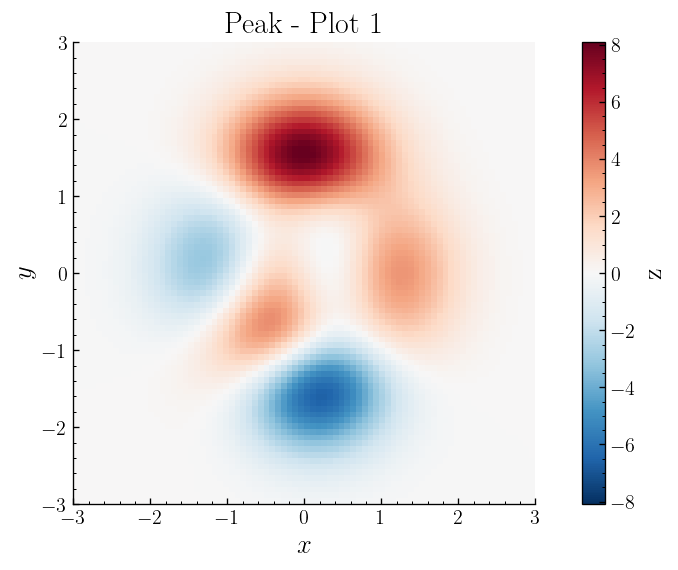

In [ ]:
# Límite simétrico para el colormap divergente
vlim = max(abs(z.min()), abs(z.max()))   # ≈ 8.1

fig, ax = plt.subplots(figsize=(10, 5))

# ── imshow ────────────────────────────────────────────────────────────────
# origin='lower': el eje y crece hacia arriba (convenio matemático)
# extent=[xmin, xmax, ymin, ymax]: asigna coordenadas reales a los píxeles
# aspect='equal': escala 1:1 en ambos ejes
# Nota: z debe ser (filas, columnas) = (ny, nx); aquí x varía en filas
# → transponemos z para que x quede en el eje horizontal
im0 = ax.imshow(
    z.T,                          # .T porque mgrid pone x en el primer eje
    origin='lower',               # eje y hacia arriba
    extent=[-3, 3, -3, 3],        # coordenadas reales
    cmap='RdBu_r',             # twilight
    vmin=-vlim, vmax=vlim,        # centrado en 0
    aspect='equal',
)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Peak - Plot 1')
plt.colorbar(im0, ax=ax, label='z', fraction=0.046)

plt.show()

## 3. ¿Qué representación es más adecuada?

Tenemos cuatro herramientas principales para visualizar un campo escalar 2D.
Cada una revela aspectos distintos del mismo dato — la elección depende
de qué quieres comunicar.

### Herramientas disponibles

| Herramienta | Qué muestra bien | Limitación principal |
|---|---|---|
| `imshow` | Campo rasterizado como imagen; rápido para datos en píxeles | Requiere malla regular; eje y invertido por defecto |
| `pcolor` | Campo con coordenadas reales y malla no uniforme | Lento en datos grandes (dibuja polígonos uno a uno) |
| `pcolormesh` | Igual que `pcolor` pero vectorizado sobre toda la malla | Ligeramente más lento que `imshow` |
| `contourf` | Estructura de niveles; bandas de igual valor | Pierde variación dentro de cada banda |
| `plot_surface` | Topografía: picos, valles, sillas de montar | Perspectiva distorsiona magnitudes; partes traseras ocultas |

### `imshow` vs `pcolor` vs `pcolormesh`

La diferencia no es estética: es de **convenio de coordenadas e implementación**.

```python
# imshow: lee el array como una imagen
# → fila 0 = parte SUPERIOR de la figura (como una pantalla)
# → corregir con origin='lower' y extent=[xmin, xmax, ymin, ymax]
# → sólo mallas regulares
plt.imshow(Z, origin='lower', extent=[-3, 3, -3, 3], cmap='RdBu_r')

# pcolor: dibuja cada celda como un polígono independiente
# → acepta coordenadas reales y mallas NO uniformes
# → muy flexible pero lento en arrays grandes
plt.pcolor(X, Y, Z, cmap='RdBu_r')

# pcolormesh: hace lo mismo que pcolor pero vectorizado
# → estándar recomendado para datos científicos
# → shading='auto' evita warnings en matplotlib ≥ 3.3
plt.pcolormesh(X, Y, Z, cmap='RdBu_r', shading='auto')
```

| | `imshow` | `pcolor` | `pcolormesh` |
|---|---|---|---|
| **Origen por defecto** | superior-izquierda ⚠ | inferior-izquierda ✓ | inferior-izquierda ✓ |
| **Coordenadas reales** | sólo via `extent=` | arrays `X`, `Y` directamente | arrays `X`, `Y` directamente |
| **Grilla no uniforme** | ❌ | ✓ | ✓ |
| **Velocidad** | muy rápida | lenta | rápida |
| **Implementación** | rasterización directa | polígonos individuales | malla vectorizada |
| **Uso típico** | imágenes, píxeles | -- | estándar científico |

---

> **Regla práctica**:
> - Imagen → `imshow`
> - Datos con coordenadas físicas ($x$, $y$ en metros, grados…) → `pcolormesh`


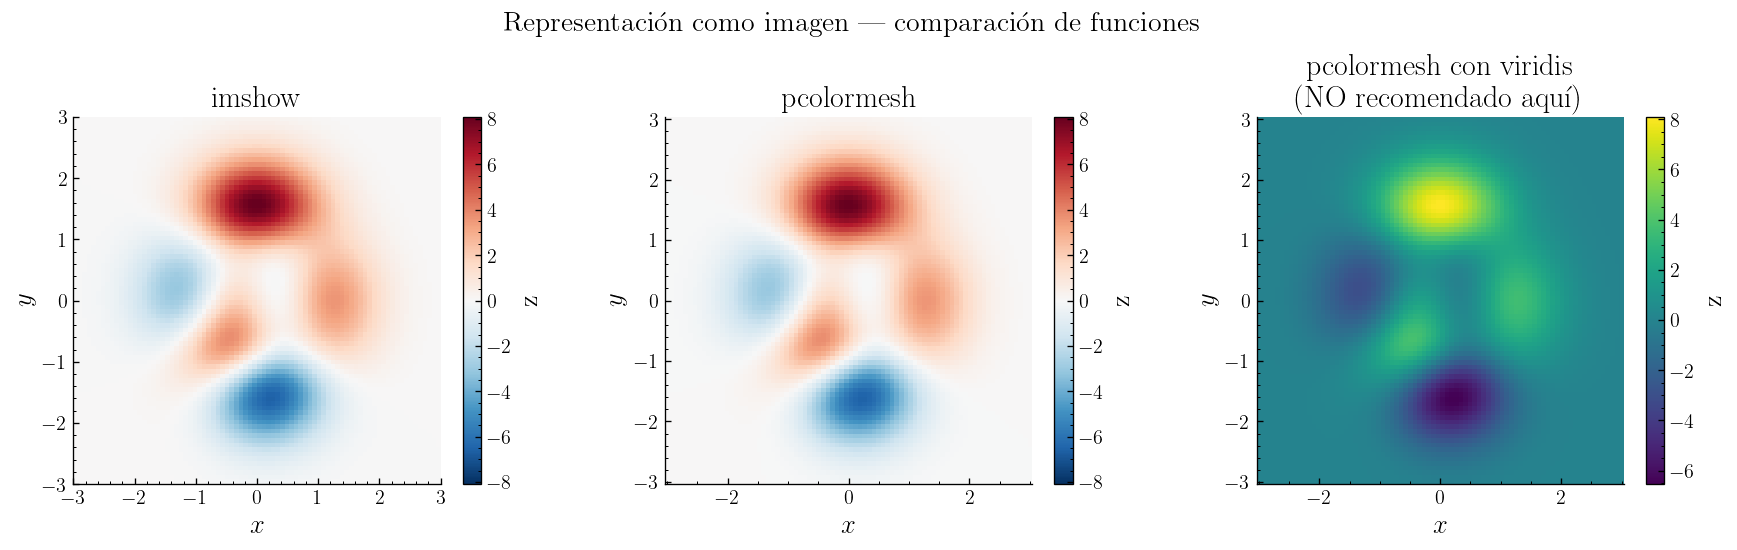

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Representación como imagen — comparación de funciones')

# Límite simétrico para el colormap divergente
vlim = max(abs(z.min()), abs(z.max()))   # ≈ 8.1

# ── imshow ────────────────────────────────────────────────────────────────
# origin='lower': el eje y crece hacia arriba (convenio matemático)
# extent=[xmin, xmax, ymin, ymax]: asigna coordenadas reales a los píxeles
# aspect='equal': escala 1:1 en ambos ejes
# Nota: z debe ser (filas, columnas) = (ny, nx); aquí x varía en filas
# → transponemos z para que x quede en el eje horizontal
im0 = axes[0].imshow(
    z.T,                          # .T porque mgrid pone x en el primer eje
    origin='lower',               # eje y hacia arriba
    extent=[-3, 3, -3, 3],        # coordenadas reales
    cmap='RdBu_r',                # divergente: rojo=positivo, azul=negativo
    vmin=-vlim, vmax=vlim,        # centrado en 0
    aspect='equal',
)
axes[0].set_title('imshow')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
plt.colorbar(im0, ax=axes[0], label='z', fraction=0.046)

# ── pcolormesh ────────────────────────────────────────────────────────────
# Acepta los arrays X, Y directamente → no necesita extent ni transponer
# shading='auto': ajusta el sombreado según la forma de los arrays
pc = axes[1].pcolormesh(
    x, y, z,
    cmap='RdBu_r',
    vmin=-vlim, vmax=vlim,
    shading='auto',
)
axes[1].set_title('pcolormesh')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
plt.colorbar(pc, ax=axes[1], label='z', fraction=0.046)

# ── pcolormesh con colormap secuencial (para comparar) ────────────────────
pc2 = axes[2].pcolormesh(x, y, z, cmap='viridis', shading='auto')
axes[2].set_title('pcolormesh con viridis\n(NO recomendado aquí)')
axes[2].set_xlabel('$x$'); axes[2].set_ylabel('$y$')
axes[2].set_aspect('equal')
plt.colorbar(pc2, ax=axes[2], label='z', fraction=0.046)
# El cero no tiene color especial → no se distingue positivo de negativo

plt.tight_layout()
plt.show()

# ```python
# # shading='flat': cada celda toma el color de su esquina (i,j)
# # Z debe tener shape (ny-1, nx-1) si X,Y definen los BORDES de las celdas
# ax.pcolormesh(X, Y, Z, shading='flat')

# # shading='nearest': colorea cada celda con el punto más cercano
# # Z puede tener el mismo shape que X, Y (centros de celda)
# ax.pcolormesh(X, Y, Z, shading='nearest')

# # shading='auto' (recomendado): elige automáticamente según la forma de Z
# ax.pcolormesh(X, Y, Z, shading='auto')
# ```

**Observación**: con `viridis` (panel derecho) no hay forma de saber a simple vista dónde $z > 0$ y dónde $z < 0$. Con `RdBu_r` el cero queda en blanco y los signos son inmediatamente legibles.

> **Por qué transponemos en `imshow`**  
> `np.mgrid[-3:3:n*1j, -3:3:n*1j]` devuelve `x` con forma `(n, n)` donde el **primer índice** varía en la primera coordenada (que asignamos a $x$). Pero `imshow` interpreta las filas como $y$ y las columnas como $x$. La transposición `.T` corrige esto. `pcolormesh` no tiene ese problema porque acepta los arrays de coordenadas explícitamente.

---
## 4. Superficie deformada

Elevar el valor $z$ como una tercera dimensión geométrica permite ver la **topografía** del campo: dónde hay picos, valles, crestas y sillas de montar. La contrapartida es que las partes traseras quedan ocluidas y la perspectiva puede engañar.


> `view_init(elev, azim)`:  
> - `elev` = ángulo de elevación respecto al plano $xy$ (0° = visto de lado, 90° = visto desde arriba).  
> - `azim` = rotación horizontal en grados.

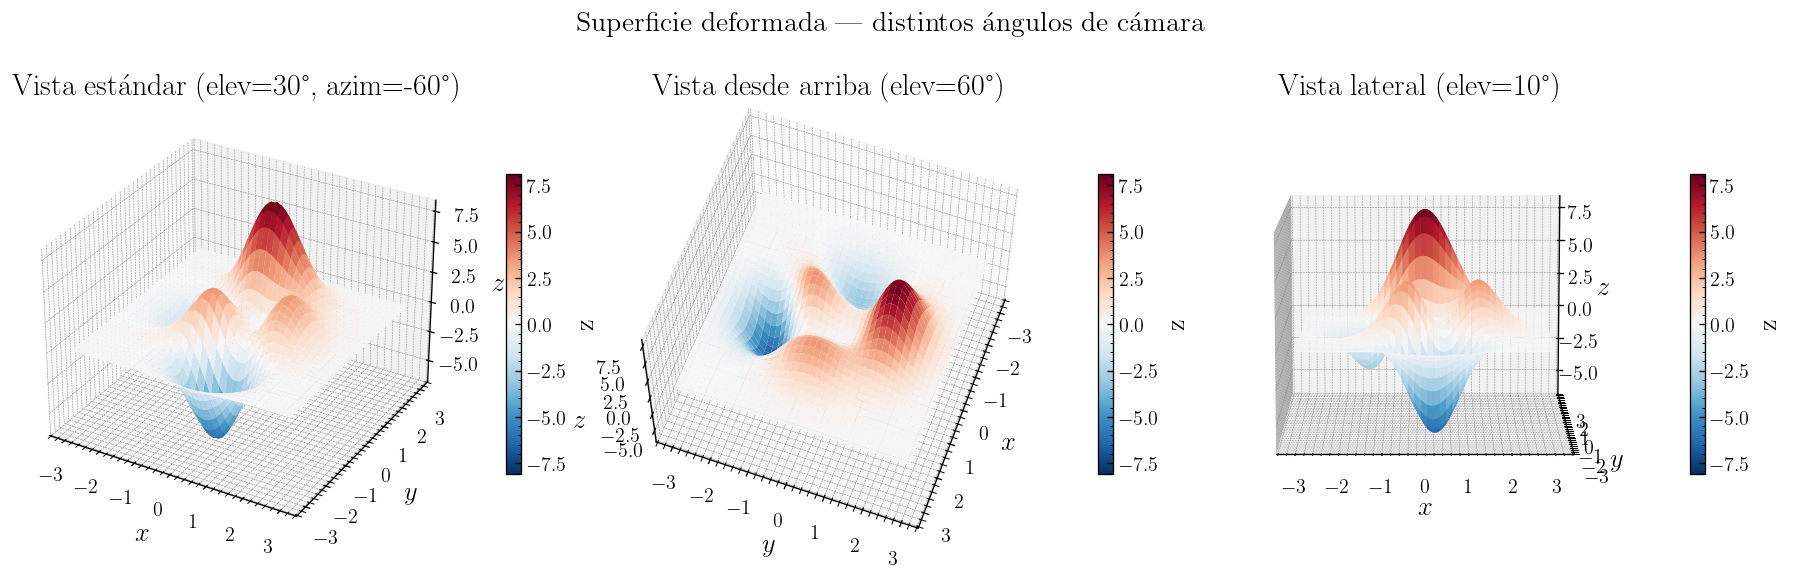

In [ ]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Superficie deformada — distintos ángulos de cámara')

vistas = [
    (30, -60,  'Vista estándar (elev=30°, azim=-60°)'),
    (60,  20,  'Vista desde arriba (elev=60°)'),
    (10, -90,  'Vista lateral (elev=10°)'),
]

for i, (elev, azim, titulo) in enumerate(vistas):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    # plot_surface: dibuja la malla de cuadriláteros con color según z
    # rstride/cstride: submuestreo de filas/columnas para la malla de aristas
    # linewidth=0: no dibuja las aristas de la malla (más limpio)
    # antialiased=False: más rápido; True mejora la apariencia pero es más lento
    surf = ax.plot_surface(
        x, y, z,
        cmap='RdBu_r',
        vmin=-vlim, vmax=vlim,
    )
    ax.set_title(titulo)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_zlabel('$z$')

    ax.view_init(elev=elev, azim=azim)  # ángulo de cámara

    fig.colorbar(surf, ax=ax, fraction=0.03, pad=0.1, label='z', shrink=0.6)

plt.tight_layout()
plt.show()

---
## 5. Isocontornos y superficies

Un **isocontorno** (o curva de nivel) es el conjunto de puntos donde $f(x,y) = c$ para un valor constante $c$. Son el análogo 2D de las curvas de nivel de un mapa topográfico.

| Función | Qué dibuja |
|---|---|
| `contour` | Sólo las líneas (isolíneas) |
| `contourf` | Rellena las bandas entre isolíneas con color |

Ambas aceptan `levels`: un entero (número de niveles automáticos) o un array explícito de valores.

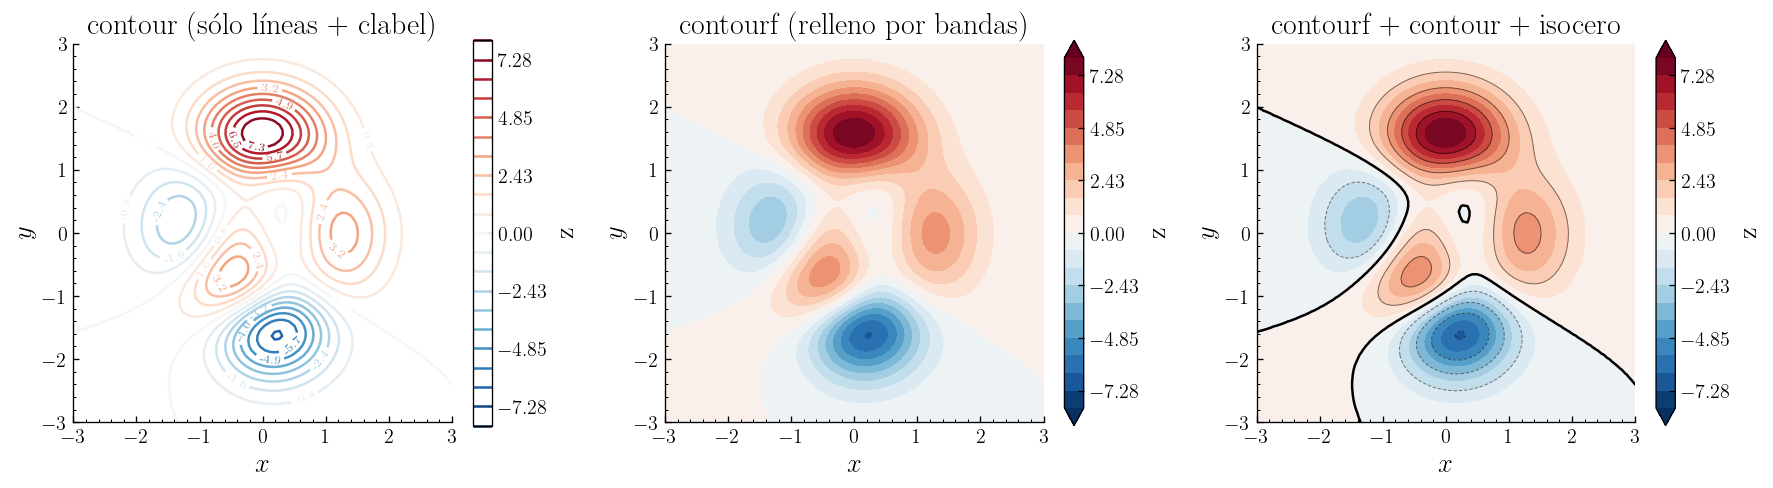

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Niveles simétricos alrededor del cero para el colormap divergente
levels = np.linspace(-vlim, vlim, 21)   # 20 intervalos, 21 bordes

# ── contour: sólo líneas ───────────────────────────────────────────────────
cs0 = axes[0].contour(
    x, y, z,
    levels=levels,
    cmap='RdBu_r',
)
# clabel: etiqueta las isolíneas con su valor numérico
# inline=True: "corta" la línea donde pone la etiqueta para que no se solape
# fmt='%.1f': formato de número con 1 decimal
axes[0].clabel(cs0, inline=True, fontsize=7, fmt='%.1f')
axes[0].set_title('contour (sólo líneas + clabel)')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')
plt.colorbar(cs0, ax=axes[0], label='z', fraction=0.046)

# ── contourf: relleno por bandas ───────────────────────────────────────────
# extend='both': valores fuera de [levels[0], levels[-1]] se colorean
#                con el color extremo en lugar de quedar sin color
cf1 = axes[1].contourf(
    x, y, z,
    levels=levels,
    cmap='RdBu_r',
    extend='both',
)
axes[1].set_title('contourf (relleno por bandas)')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
cbar = plt.colorbar(cf1, ax=axes[1], label='z', fraction=0.046)
# Los triángulos en los extremos de la barra indican 'extend'

# ── contourf + contour superpuestos ───────────────────────────────────────
# Esta combinación es la más completa: relleno + estructura de líneas
cf2 = axes[2].contourf(x, y, z, levels=levels, cmap='RdBu_r', extend='both')
cs2 = axes[2].contour(
    x, y, z,
    levels=levels[::2],   # sólo 1 de cada 2 niveles para no saturar
    colors='black',
    linewidths=0.6,
    alpha=0.5,
)
# Línea especial para z=0 (isocero) más visible
axes[2].contour(x, y, z, levels=[0], colors='black', linewidths=1.5)
axes[2].set_title('contourf + contour + isocero')
axes[2].set_xlabel('$x$'); axes[2].set_ylabel('$y$')
axes[2].set_aspect('equal')
plt.colorbar(cf2, ax=axes[2], label='z', fraction=0.046)

plt.tight_layout()
plt.show()

**Observa**: dibujar la isocero ($z = 0$) con línea más gruesa es una buena práctica cuando el campo tiene signo: delimita visualmente las regiones positivas de las negativas.

---

También se pueden proyectar las curvas de nivel sobre la superficie 3D o sobre el plano base. Esto combina la topografía de la superficie con la información de los isocontornos.

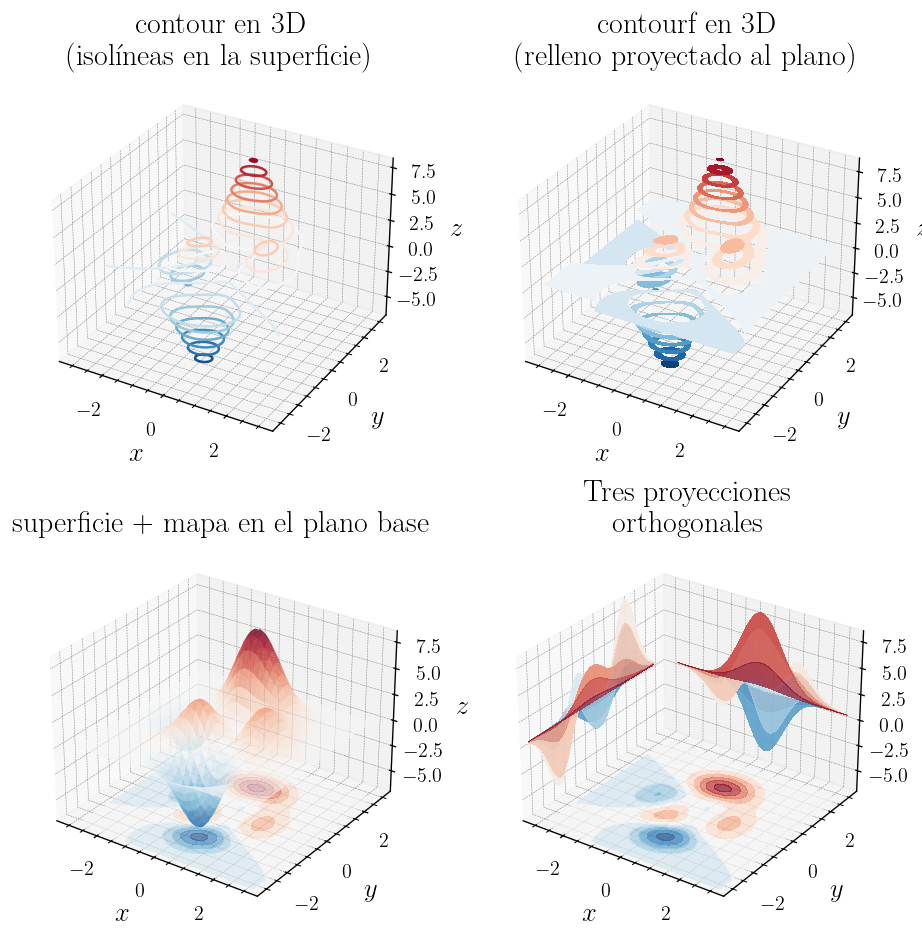

In [ ]:
fig = plt.figure(figsize=(8, 8))

# ── ax.contour en 3D: líneas sobre la superficie ──────────────────────────
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# contour 3D: dibuja las curvas de nivel flotando a la altura correcta de z
ax1.contour(x, y, z, levels=15, cmap='RdBu_r')
ax1.set_title('contour en 3D\n(isolíneas en la superficie)')
ax1.set_xlabel('$x$'); ax1.set_ylabel('$y$'); ax1.set_zlabel('$z$')
ax1.view_init(elev=30, azim=-60)

# ── ax.contourf en 3D: relleno proyectado en el plano base ───────────────
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.contourf(x, y, z, levels=15, cmap='RdBu_r')
ax2.set_title('contourf en 3D\n(relleno proyectado al plano)')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$'); ax2.set_zlabel('$z$')
ax2.view_init(elev=30, azim=-60)

# ── superficie + proyección de contourf en z=zmin ────────────────────────
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# Superficie semitransparente
ax3.plot_surface(x, y, z, cmap='RdBu_r', vmin=-vlim, vmax=vlim,
                 linewidth=0, alpha=0.6, rstride=2, cstride=2)

# Proyección de contourf en el plano z = zmin (debajo de la superficie)
# zdir='z', offset=z.min(): proyecta sobre el plano horizontal inferior
ax3.contourf(x, y, z, levels=12, cmap='RdBu_r',
             zdir='z', offset=z.min() - 1, alpha=0.6)
ax3.set_title('superficie + mapa en el plano base')
ax3.set_xlabel('$x$'); ax3.set_ylabel('$y$'); ax3.set_zlabel('$z$')
ax3.view_init(elev=28, azim=-55)

# ── Panel 4: tres proyecciones ortogonales ────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# Proyección en plano xy (zdir='z')
ax4.contourf(x, y, z, levels=10, cmap='RdBu_r',
             zdir='z', offset=z.min() - 1.0, alpha=0.7)
# Proyección en plano xz (zdir='y')
ax4.contourf(x, y, z, levels=10, cmap='RdBu_r',
             zdir='y', offset=3.5, alpha=0.7)
# Proyección en plano yz (zdir='x')
ax4.contourf(x, y, z, levels=10, cmap='RdBu_r',
             zdir='x', offset=-3.5, alpha=0.7)
ax4.set_title('Tres proyecciones\northogonales')
ax4.set_xlabel('$x$'); ax4.set_ylabel('$y$'); ax4.set_zlabel('$z$')
ax4.view_init(elev=28, azim=-55)


plt.tight_layout()
plt.show()

### Importante: Barras de color — configuración detallada

La barra de color (`colorbar`) es parte esencial de cualquier figura de campo escalar: sin ella el color no tiene significado cuantitativo.

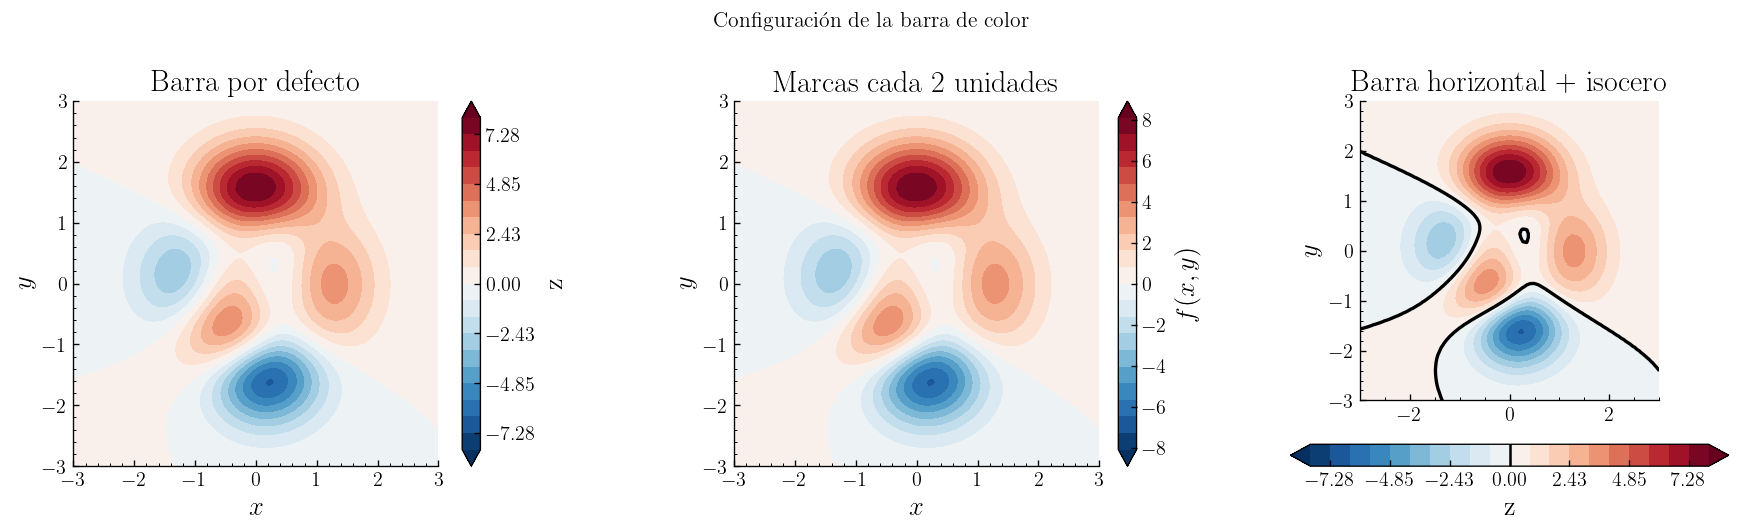

In [ ]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Configuración de la barra de color', fontsize=13)

# ── Barra básica ──────────────────────────────────────────────────────────
cf0 = axes[0].contourf(x, y, z, levels=levels, cmap='RdBu_r', extend='both')
cbar0 = plt.colorbar(cf0, ax=axes[0], label='z')
axes[0].set_title('Barra por defecto')
axes[0].set_aspect('equal')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')

# ── Barra con marcas personalizadas ───────────────────────────────────────
cf1 = axes[1].contourf(x, y, z, levels=levels, cmap='RdBu_r', extend='both')
cbar1 = plt.colorbar(cf1, ax=axes[1], label='$f(x,y)$',
                     fraction=0.046,  # ancho de la barra relativo al eje
                     pad=0.04)        # separación entre eje y barra
# Marcas cada 2 unidades con formato explícito
cbar1.set_ticks(np.arange(-8, 9, 2))
axes[1].set_title('Marcas cada 2 unidades')
axes[1].set_aspect('equal')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')

# ── Barra horizontal + isolínea cero resaltada ────────────────────────────
cf2 = axes[2].contourf(x, y, z, levels=levels, cmap='RdBu_r', extend='both')
axes[2].contour(x, y, z, levels=[0], colors='black', linewidths=2)
# orientation='horizontal': barra debajo de la figura
cbar2 = plt.colorbar(cf2, ax=axes[2], label='z',
                     orientation='horizontal',
                     fraction=0.06, pad=0.12)
cbar2.ax.axvline(0, color='black', lw=1.5)  # marca el cero en la barra
axes[2].set_title('Barra horizontal + isocero')
axes[2].set_aspect('equal')
axes[2].set_ylabel('$y$')

plt.tight_layout()
plt.show()

---
## Ejercicio 1

Considere el siguiente campo escalar generado con la función de Himmelblau, definida como:

$$g(x,y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$$

Esta función tiene **cuatro mínimos globales** iguales a cero y un máximo local. Es un clásico de optimización.

**Tarea**: producir una figura (o varias) que muestre claramente dónde están los cuatro mínimos.

1. ¿Qué tipo de colormap es conveniente?
2. Considerar usar escala logarítmica: `norm=mcolors.LogNorm()`. ¿Para qué?
3. Los mínimos están en $(x,y) \approx (3, 2),\ (-2.8, 3.1),\ (-3.8, -3.3),\ (3.6, -1.8)$.
4. Combinar al menos dos representaciones.

In [ ]:
# Datos del ejercicio
xh, yh = np.mgrid[-5:5:150j, -5:5:150j]
g = (xh**2 + yh - 11)**2 + (xh + yh**2 - 7)**2

print('Mínimos exactos: (3,2), (-2.805,3.131), (-3.779,-3.283), (3.584,-1.848)')


Mínimos exactos: (3,2), (-2.805,3.131), (-3.779,-3.283), (3.584,-1.848)


---
## Ejercicio 2: temperatura superficial del mar (SST)

Considere un campo de **temperatura superficial del mar (SST)** sintético que simula:
- una corriente cálida de oeste a este en el ecuador,
- enfriamiento hacia los polos,
- giros oceánicos de mesoescala,
- ruido de pequeña escala (turbulencia).

**Tarea:**
1. Identificar qué colormap es apropiado para la SST absoluta y para la anomalía.
2. Haz al menos dos representaciones distintas.
3. Añade colorbars correctamente configuradas.
4. Anota en la figura al menos un rasgo físico visible.

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# DATOS DEL EJERCICIO: SST sintética
# ════════════════════════════════════════════════════════════════════════════

from scipy.ndimage import gaussian_filter

np.random.seed(0)
N_ej = 300

# Dominio: longitud ∈ [−π, π],  latitud ∈ [−π/2, π/2]
lon = np.linspace(-np.pi, np.pi, N_ej)
lat = np.linspace(-np.pi/2, np.pi/2, N_ej)
LON, LAT = np.meshgrid(lon, lat)

# Temperatura media: decrece hacia los polos siguiendo la radiación solar
# cos(LAT)^1.5 es más realista que cos(LAT) simple
T_media = 28 * np.cos(LAT)**1.5

# Corriente ecuatorial cálida: gaussiana estrecha en latitud, oscilante en longitud
T_corriente = 4 * np.exp(-8 * LAT**2) * np.sin(2 * LON)

# Giros oceánicos: estructuras de mesoescala (±300 km)
T_giros = (
    3 * np.exp(-6*((LON+1.5)**2 + (LAT-0.8)**2))   # giro anticiclónico cálido
  - 3 * np.exp(-6*((LON-1.5)**2 + (LAT-0.8)**2))   # giro ciclónico frío
  - 2 * np.exp(-6*(LON**2 + (LAT+0.9)**2))           # giro frío en el hemisferio sur
)

# Ruido de pequeña escala: turbulencia oceánica suavizada espacialmente
ruido_base = np.random.randn(N_ej, N_ej)
ruido = gaussian_filter(ruido_base, sigma=4)   # suavizado gaussiano (sigma=4 celdas)

# Campo total = media + corriente + giros + ruido
SST = T_media + T_corriente + T_giros + 0.5 * ruido

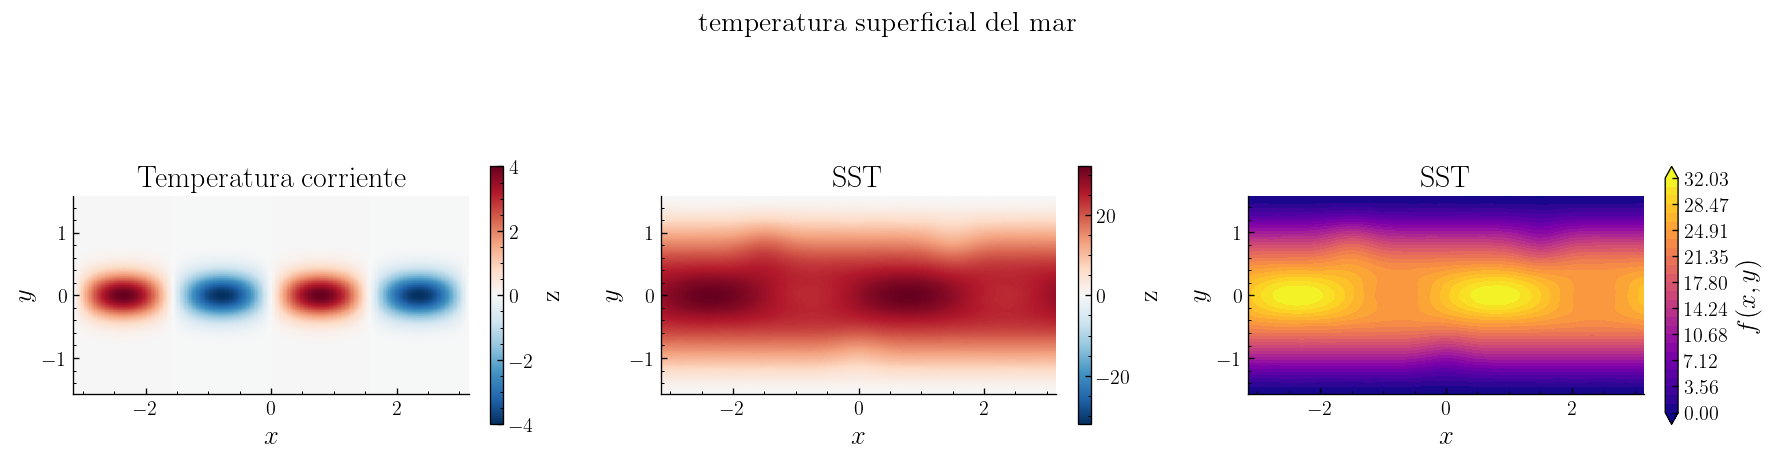

In [112]:
import matplotlib.ticker as ticker
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('temperatura superficial del mar')

# Límite simétrico para el colormap divergente
vlim = max(abs(SST.min()), abs(SST.max()))   # ≈ 8.1
vlim2= max(abs(T_corriente.min()), abs(T_corriente.max()))

# ── pcolormesh ────────────────────────────────────────────────────────────
# Acepta los arrays X, Y directamente → no necesita extent ni transponer
# shading='auto': ajusta el sombreado según la forma de los arrays
pc = axes[0].pcolormesh(
    LON, LAT, T_corriente,
    cmap='RdBu_r',
    vmin=-vlim2, vmax=vlim2,
    shading='auto',
)
axes[0].set_title('Temperatura corriente')
axes[0].set_xlabel('$x$'); axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')
# 3. Crear la colorbar y guardarla en la variable 'cbar'
cbar = plt.colorbar(pc, ax=axes[0], label='z', fraction=0.030)

# 4. Pedir exactamente 5 números distribuidos uniformemente
# Usamos np.linspace para que calcule los pasos exactos entre -vlim y vlim
cbar.set_ticks(np.linspace(-vlim2, vlim2, 5))

# ── pcolormesh ────────────────────────────────────────────────────────────
# Acepta los arrays X, Y directamente → no necesita extent ni transponer
# shading='auto': ajusta el sombreado según la forma de los arrays
pc = axes[1].pcolormesh(
    LON, LAT, SST,
    cmap='RdBu_r',
    vmin=-vlim, vmax=vlim,
    shading='auto',
)
axes[1].set_title('SST')
axes[1].set_xlabel('$x$'); axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
plt.colorbar(pc, ax=axes[1], label='z', fraction=0.030)

# ── pcolormesh con colormap secuencial (para comparar) ────────────────────
# Al usar un número impar de niveles (ej. 21), el 0 queda justo en un corte de color
levels = np.linspace(0, vlim, 28)
# 2. Graficar (RdBu_r tiene el blanco en el centro)
cf1 = axes[2].contourf(LON, LAT, SST, levels=levels, cmap='plasma',extend='both')
# 3. Barra de colores
bcf=plt.colorbar(cf1, ax=axes[2], label='$f(x,y)$', fraction=0.030)


axes[2].set_title('SST')
axes[2].set_xlabel('$x$'); axes[2].set_ylabel('$y$')
axes[2].set_aspect('equal')

# El cero no tiene color especial → no se distingue positivo de negativo

plt.tight_layout()
plt.show()



In [ ]:
# Al usar un número impar de niveles (ej. 21), el 0 queda justo en un corte de color
levels = np.linspace(-vlim, vlim, 21)
# 2. Graficar (RdBu_r tiene el blanco en el centro)
cf1 = axes[2].plt.contourf(LON, LAT, SST, levels=levels, cmap='RdBu', extend='both')
# 3. Barra de colores
plt.colorbar(cf1, ax=axes[2], label='$f(x,y)$', fraction=0.046)

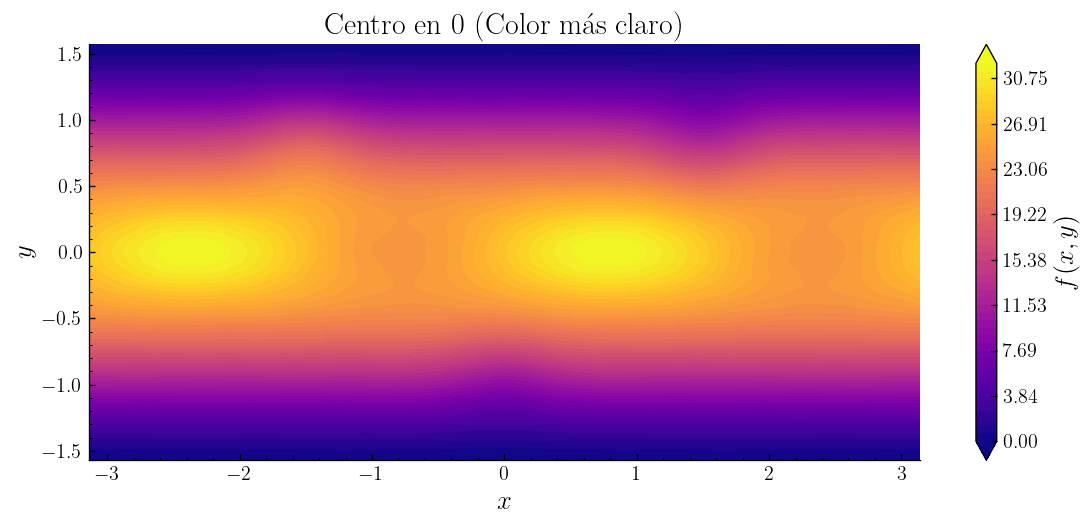

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Forzar simetría para que el 0 sea el blanco central
vlim = max(abs(SST.min()), abs(SST.max()))
# Al usar un número impar de niveles (ej. 21), el 0 queda justo en un corte de color
levels = np.linspace(0, vlim, 51)

plt.figure(figsize=(15, 4.5))

# 2. Graficar (RdBu_r tiene el blanco en el centro)
cf1 = plt.contourf(LON, LAT, SST, levels=levels, cmap='plasma', extend='both')

# 3. Barra de colores
cbar1 = plt.colorbar(cf1, label='$f(x,y)$', fraction=0.046, pad=0.04)

# 4. Personalizar las marcas (ticks)
#cbar1.set_ticks(np.arange(-8, 9, 2))

plt.title('Centro en 0 (Color más claro)')
plt.gca().set_aspect('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.show()

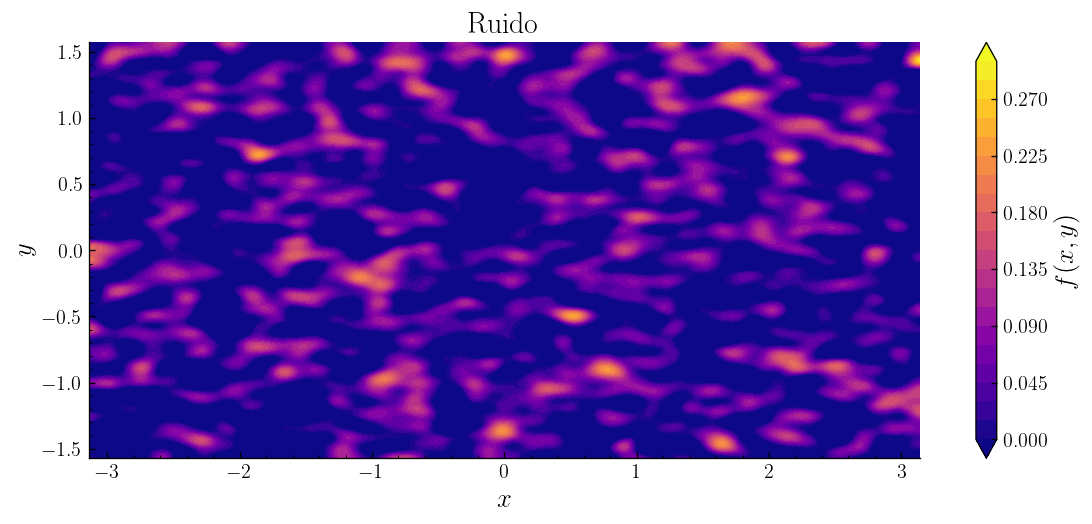

In [103]:


# 1. Forzar simetría para que el 0 sea el blanco central
vlim = max(abs(SST.min()), abs(SST.max()))
# Al usar un número impar de niveles (ej. 21), el 0 queda justo en un corte de color
levels = np.linspace(0, 0.3, 21)

plt.figure(figsize=(15, 4.5))

# 2. Graficar (RdBu_r tiene el blanco en el centro)
cf1 = plt.contourf(LON, LAT, ruido, levels=levels, cmap='plasma', extend='both')

# 3. Barra de colores
cbar1 = plt.colorbar(cf1, label='$f(x,y)$', fraction=0.046, pad=0.04)

# 4. Personalizar las marcas (ticks)
#cbar1.set_ticks(np.arange(-8, 9, 2))

plt.title('Ruido')
plt.gca().set_aspect('equal')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.show()